### Import Packages

In [24]:
import os
import tifffile
import numpy as np
import nibabel as nib

In [25]:
# Import basic packages for later use
import os
import shutil
from collections import OrderedDict

import json
import matplotlib.pyplot as plt
import nibabel as nib

import numpy as np
import torch

In [26]:
# check whether GPU accelerated computing is available
assert torch.cuda.is_available() # if there is an error here, enable GPU in the Runtime

In [27]:
torch.__version__

'2.2.1'

In [28]:
# check if nnunet can be imported
import nnunetv2

In [29]:
def make_if_dont_exist(folder_path,overwrite=False):
    """
    creates a folder if it does not exists
    input: 
    folder_path : relative path of the folder which needs to be created
    over_write :(default: False) if True overwrite the existing folder 
    """
    if os.path.exists(folder_path):
        
        if not overwrite:
            print(f"{folder_path} exists.")
        else:
            print(f"{folder_path} overwritten")
            shutil.rmtree(folder_path)
            os.makedirs(folder_path)

    else:
      os.makedirs(folder_path)
      print(f"{folder_path} created!")

In [30]:
root_dir = '/home/home/Documents'

In [31]:
mount_dir = root_dir
mount_dir = '/media/home/DATA10TB/MITOCHONDRIA/'

In [32]:
# Maybe move path of preprocessed data directly on content - this may be signifcantely faster!
print("Current Working Directory {}".format(os.getcwd()))
path_dict = {
    "nnUNet_raw" : '/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw', 
    "nnUNet_preprocessed" : os.path.join(mount_dir, "nnUNet_preprocessed"), # 1 experiment: 1 epoch took 112s
    "nnUNet_results" : os.path.join(mount_dir, "nnUNet_results"),
    "RAW_DATA_PATH" : os.path.join(mount_dir, "RawData"), # This is used here only for convenience (not necessary for nnU-Net)!
}
# Write paths to environment variables

for env_var, path in path_dict.items():
  os.environ[env_var] = path 

# Check whether all environment variables are set correct!
for env_var, path in path_dict.items():
  if os.getenv(env_var) != path:
    print("Error:")
    print("Environment Variable {} is not set correctly!".format(env_var))
    print("Should be {}".format(path))
    print("Variable is {}".format(os.getenv(env_var)))
  make_if_dont_exist(path, overwrite=False)

print("If No Error Occured Continue Forward. =)")

Current Working Directory /home/home/Documents
/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw exists.
/media/home/DATA10TB/MITOCHONDRIA/nnUNet_preprocessed exists.
/media/home/DATA10TB/MITOCHONDRIA/nnUNet_results exists.
/media/home/DATA10TB/MITOCHONDRIA/RawData exists.
If No Error Occured Continue Forward. =)


In [33]:
# Create Folderstructure for the new dataset!
dataset_name = 'Dataset3005_Mitochondria' #change here for different dataset name
nnunet_raw_data = os.path.join(os.getenv("nnUNet_raw"))
task_folder_name = os.path.join(nnunet_raw_data,dataset_name)
train_image_dir = os.path.join(task_folder_name,'imagesTr')
train_label_dir = os.path.join(task_folder_name,'labelsTr')
test_dir = os.path.join(task_folder_name,'imagesTs')

# Create Folder Structure for the SCGM dataset on the system
make_if_dont_exist(task_folder_name)
make_if_dont_exist(train_image_dir)
make_if_dont_exist(train_label_dir)
make_if_dont_exist(test_dir)

/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw/Dataset3005_Mitochondria exists.
/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw/Dataset3005_Mitochondria/imagesTr exists.
/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw/Dataset3005_Mitochondria/labelsTr exists.
/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw/Dataset3005_Mitochondria/imagesTs exists.


In [34]:
training_data_name="Dataset3005_Mitochondria"
test_data_name="Dataset3005_Mitochondria"

In [35]:
base_dir = '/home/home/Documents'

In [36]:
os.chdir(base_dir)

## 3D Data Prep

In [37]:
import os
import random
import numpy as np
import nibabel as nib
import tifffile
import shutil
import json

def process_raw_label_chunks(
    raw_stack,
    label_stack,
    raw_chunks_dir,
    label_chunks_dir,
    count,
    chunk_size=(64, 512, 512),
    stride=(32, 256, 256),
    max_wiggle_room_percentage=50,
    label_threshold=0.0,
    test_mode=False
):
    """
    Extract sub-volumes (chunks) of both raw and label data from the same coordinates,
    ensuring they stay strictly in sync. Only saves the chunk pair if the label chunk
    meets the non-zero threshold.

    Parameters
    ----------
    raw_stack : np.ndarray
        3D array (z, y, x) for raw data.
    label_stack : np.ndarray
        3D array (z, y, x) for corresponding label data (same shape as raw_stack).
    raw_chunks_dir : str
        Directory for saving raw chunks.
    label_chunks_dir : str
        Directory for saving label chunks.
    count : int
        The starting chunk index.
    chunk_size : tuple of ints
        (z, y, x) size of the chunks to extract.
    stride : tuple of ints
        (z, y, x) stride for moving the extraction window (overlap).
    max_wiggle_room_percentage : float
        Max allowed padding or shift as a percentage of chunk dimensions.
    label_threshold : float
        Minimum fraction of non-zero voxels in the label chunk to keep it.
    test_mode : bool
        If True, do not write files to disk; only simulate.

    Returns
    -------
    count : int
        Updated chunk index after processing.
    created_raw_files : list
        List of raw chunk filenames saved (if not in test mode).
    created_label_files : list
        List of label chunk filenames saved (if not in test mode).
    """

    z, y, x = raw_stack.shape
    # Sanity check: label stack should match raw stack shape
    if label_stack.shape != (z, y, x):
        print("[ERROR] Label stack shape does not match raw stack shape. Skipping.")
        return count, [], []

    # Check padding requirement
    need_padding = False
    pad_z = pad_y = pad_x = 0
    if z < chunk_size[0]:
        pad_z = chunk_size[0] - z
        need_padding = True
    if y < chunk_size[1]:
        pad_y = chunk_size[1] - y
        need_padding = True
    if x < chunk_size[2]:
        pad_x = chunk_size[2] - x
        need_padding = True

    total_padding = pad_z * y * x + pad_y * z * x + pad_x * z * y
    total_chunk_volume = np.prod(chunk_size)
    if total_chunk_volume == 0:
        print("[ERROR] Chunk volume is zero or invalid. Skipping.")
        return count, [], []

    padding_percentage = 100 * total_padding / total_chunk_volume
    if need_padding and padding_percentage <= max_wiggle_room_percentage:
        print(f"Padding required: Z={pad_z}, Y={pad_y}, X={pad_x}")
        raw_stack = np.pad(raw_stack, ((0, pad_z), (0, pad_y), (0, pad_x)), 'constant')
        label_stack = np.pad(label_stack, ((0, pad_z), (0, pad_y), (0, pad_x)), 'constant')
        z, y, x = raw_stack.shape
        print(f"[INFO] After padding: new shape = {z}, {y}, {x}")
    elif need_padding and padding_percentage > max_wiggle_room_percentage:
        print(f"[WARNING] Padding exceeds {max_wiggle_room_percentage}% of chunk volume. Skipping.")
        return count, [], []
    else:
        print("[INFO] No padding needed.")

    # Helper to compute start positions for each dimension
    def compute_starts(dim_size, chunk_dim, stride_dim):
        positions = []
        pos = 0
        while pos + chunk_dim <= dim_size:
            positions.append(pos)
            pos += stride_dim
        if positions:
            last_pos = positions[-1]
            last_chunk_end = last_pos + chunk_dim
            remaining = dim_size - last_chunk_end
            # If there's a "significant" leftover (>= half stride), add a final chunk start
            if remaining >= stride_dim // 2 and last_chunk_end < dim_size:
                positions.append(dim_size - chunk_dim)
        else:
            # If dimension smaller than chunk size, place at 0
            positions.append(0)
        return positions

    z_starts = compute_starts(z, chunk_size[0], stride[0])
    y_starts = compute_starts(y, chunk_size[1], stride[1])
    x_starts = compute_starts(x, chunk_size[2], stride[2])

    print(f"[INFO] Chunk starts -> Z:{len(z_starts)}, Y:{len(y_starts)}, X:{len(x_starts)}")

    created_raw_files = []
    created_label_files = []

    # Extraction loop
    for start_z in z_starts:
        for start_y in y_starts:
            for start_x in x_starts:
                end_z = start_z + chunk_size[0]
                end_y = start_y + chunk_size[1]
                end_x = start_x + chunk_size[2]

                # Check wiggle room for Z
                if end_z > z:
                    overshoot = end_z - z
                    allowed = (max_wiggle_room_percentage / 100.0) * chunk_size[0]
                    if overshoot <= allowed:
                        start_z = z - chunk_size[0]
                        end_z = z
                    else:
                        print(f"[SKIP] Exceeds wiggle room in Z at start {start_z}")
                        continue

                # Check wiggle room for Y
                if end_y > y:
                    overshoot = end_y - y
                    allowed = (max_wiggle_room_percentage / 100.0) * chunk_size[1]
                    if overshoot <= allowed:
                        start_y = y - chunk_size[1]
                        end_y = y
                    else:
                        print(f"[SKIP] Exceeds wiggle room in Y at start {start_y}")
                        continue

                # Check wiggle room for X
                if end_x > x:
                    overshoot = end_x - x
                    allowed = (max_wiggle_room_percentage / 100.0) * chunk_size[2]
                    if overshoot <= allowed:
                        start_x = x - chunk_size[2]
                        end_x = x
                    else:
                        print(f"[SKIP] Exceeds wiggle room in X at start {start_x}")
                        continue

                # Extract raw and label
                raw_chunk = raw_stack[start_z:end_z, start_y:end_y, start_x:end_x]
                label_chunk = label_stack[start_z:end_z, start_y:end_y, start_x:end_x]

                # Ensure correct shape
                if raw_chunk.shape != tuple(chunk_size) or label_chunk.shape != tuple(chunk_size):
                    print(f"[SKIP] Mismatched chunk size at ({start_z},{start_y},{start_x}).")
                    continue

                # Check label threshold
                nonzero_fraction = np.count_nonzero(label_chunk) / label_chunk.size
                if nonzero_fraction < label_threshold:
                    print(f"[SKIP] Label chunk below threshold ({nonzero_fraction:.3f} < {label_threshold}).")
                    continue

                # ---- If we get here, we keep both chunks ----
                # Normalize raw chunk
                r_min, r_max = raw_chunk.min(), raw_chunk.max()
                if r_max > r_min:
                    raw_chunk = (raw_chunk - r_min) / (r_max - r_min) * 255
                else:
                    raw_chunk = np.zeros_like(raw_chunk)
                raw_chunk = raw_chunk.astype(np.uint8)

                # Binarize label chunk
                label_chunk = (label_chunk > 0).astype(np.uint8)

                # Build filenames
                count_str = f"{count:05d}"
                raw_filename   = os.path.join(raw_chunks_dir,   f"mitochondria_{count_str}_0000.nii.gz")
                label_filename = os.path.join(label_chunks_dir, f"mitochondria_{count_str}.nii.gz")

                # Save (if not test_mode)
                if not test_mode:
                    # Raw
                    raw_nii = nib.Nifti1Image(raw_chunk, np.eye(4))
                    nib.save(raw_nii, raw_filename)
                    # Label
                    label_nii = nib.Nifti1Image(label_chunk, np.eye(4))
                    nib.save(label_nii, label_filename)
                    print(f"[SAVE] raw  => {raw_filename}")
                    print(f"[SAVE] label => {label_filename}")
                    created_raw_files.append(raw_filename)
                    created_label_files.append(label_filename)
                else:
                    print(f"[TEST MODE] Would save:\n  RAW: {raw_filename}\n  LAB: {label_filename}")

                count += 1

    return count, created_raw_files, created_label_files


def main(
    directory,
    raw_chunks_dir,
    label_chunks_dir,
    chunk_size=(128, 352, 352),
    stride=(64, 176, 176),
    max_wiggle_room_percentage=50,
    label_threshold=0.0,
    test_mode=False,
    raw_channel=0,
    label_channel=1
):
    """
    Main function demonstrating how to load raw/label TIFF data,
    and pass them to 'process_raw_label_chunks' for strictly-synced chunk creation.

    Parameters
    ----------
    directory : str
        Path to the directory containing .tif/.tiff files.
    raw_chunks_dir : str
        Directory for the generated raw sub-volumes.
    label_chunks_dir : str
        Directory for the generated label sub-volumes.
    chunk_size : tuple
        The size of each chunk (z, y, x).
    stride : tuple
        The stride used for chunk extraction overlap (z, y, x).
    max_wiggle_room_percentage : float
        Allowed padding or shift percentage before skipping the dataset.
    label_threshold : float
        Fraction of non-zero voxels in the label needed to keep the chunk.
    test_mode : bool
        If True, no files are saved; only logs are printed.
    raw_channel : int
        Index of the raw channel in the last dimension.
    label_channel : int
        Index of the label channel in the last dimension.
    """
    # List .tif / .tiff files
    files = [f for f in os.listdir(directory) if f.lower().endswith(('.tif', '.tiff'))]
    # random.shuffle(files)

    print("Files to be processed (random order):")
    for f in files:
        print("  ", f)

    proceed = input("\nProceed with processing? (yes/no): ").strip().lower()
    if proceed != 'yes':
        print("Aborted by user.")
        return

    # Prepare an overall counter (shared by raw+label)
    existing_raw = [f for f in os.listdir(raw_chunks_dir) if f.endswith(".nii.gz")]
    if existing_raw:
        # e.g. 'mitochondria_00042_0000.nii.gz' => parse out "00042"
        counts = []
        for fname in existing_raw:
            try:
                parts = fname.split("_")  # ['mitochondria', '00042', '0000.nii.gz']
                count_str = parts[1]
                count_val = int(count_str)
                counts.append(count_val)
            except:
                pass
        global_count = max(counts) + 1 if counts else 0
    else:
        global_count = 0

    chunk_source_mapping_finetune = {}

    for file_name in files:
        full_path = os.path.join(directory, file_name)
        print("\n[PROCESSING]", file_name)

        try:
            stack = tifffile.imread(full_path)
        except Exception as e:
            print(f"[ERROR] Loading {full_path} => {e}")
            continue

        # Move color dimension to last axis if needed
        shape_arr = np.array(stack.shape)
        if raw_channel >= shape_arr.size or label_channel >= shape_arr.size:
            print(f"[ERROR] Invalid channel indices. Skipping {file_name}.")
            continue

        # If the dimension that matches .shape == 2 or 3 is not already the last axis, we move it.
        # Typically you'd have something like (Z, Y, X, C), but if it's (C, Z, Y, X), we correct that:
        if shape_arr[-1] not in (2, 3):  
            # find the color dimension if it exists
            possible_dims = np.where((shape_arr == 2) | (shape_arr == 3))[0]
            if len(possible_dims) > 0:
                color_dim = possible_dims[0]  # e.g. 0
                stack = np.moveaxis(stack, color_dim, -1)
                print(f"[INFO] Moved color dimension from axis {color_dim} to the last axis.")

        print("Stack shape after reorienting:", stack.shape)

        # Now select the channels explicitly
        if stack.shape[-1] <= max(raw_channel, label_channel):
            print(f"[ERROR] Provided channel indices ({raw_channel}, {label_channel}) "
                  f"are out of bounds for shape {stack.shape}. Skipping.")
            continue

        raw_data = stack[..., raw_channel]
        label_data = stack[..., label_channel]

        # Ensure binary labels
        label_data[label_data > 1] = 1

        # Process the chunks in sync
        new_count, raw_files, label_files = process_raw_label_chunks(
            raw_data,
            label_data,
            raw_chunks_dir,
            label_chunks_dir,
            global_count,
            chunk_size,
            stride,
            max_wiggle_room_percentage,
            label_threshold,
            test_mode
        )
        # Update global_count
        global_count = new_count

        # Record in chunk_source_mapping_finetune
        for rfile, lfile in zip(raw_files, label_files):
            rbase = os.path.basename(rfile)
            lbase = os.path.basename(lfile)
            chunk_source_mapping_finetune[rbase] = file_name
            chunk_source_mapping_finetune[lbase] = file_name

    # Save mapping if not test_mode
    if not test_mode:
        out_map = "chunk_source_mapping_finetune.json"
        with open(out_map, 'w') as f:
            json.dump(chunk_source_mapping_finetune, f, indent=4)
        print(f"[INFO] Saved chunk-source mapping => {out_map}")

    print("\n[Done] Processing complete!")

In [38]:
import pandas as pd

# show all rows and columns
pd.set_option('display.max_rows',    None)   # or e.g. 1000
pd.set_option('display.max_columns', None)   # or a specific number
# optional—allow very wide tables without wrapping:
pd.set_option('display.width',        None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

In [39]:
#!/usr/bin/env python3
from pathlib import Path
import pandas as pd
import numpy as np
import tifffile

# directory to scan
base_dir = Path('/media/home/DATA10TB/VESSEL12/FINAL')

records = []

for tif_path in base_dir.rglob('*'):
    if tif_path.suffix.lower() not in ('.tif', '.tiff'):
        continue

    try:
        # Load the full volume (you can replace this with .asarray(key=0) if your files support lazy loading)
        stack = tifffile.imread(str(tif_path))
        shape = stack.shape           # e.g. (Z, Y, X, C) or (C, Z, Y, X) or (Z, Y, X)
        nd = stack.ndim

        # Detect channel axis by looking for a dimension of size 2 or 3
        chan_axes = [i for i,s in enumerate(shape) if s in (2, 3)]
        if len(shape) == 4 and chan_axes:
            ch = chan_axes[0]
            if ch != nd - 1:
                # move the channel axis to the end
                stack = np.moveaxis(stack, ch, -1)
        elif nd == 3:
            # no extra channel dimension
            stack = stack[..., np.newaxis]  # make it (Z,Y,X,1)
        else:
            raise ValueError(f"Unexpected shape {shape}")

        # now stack.shape == (Z, Y, X, C)
        Z, Y, X, C = stack.shape

    except Exception as e:
        print(f"[ERROR] Could not read {tif_path.name}: {e}")
        continue

    records.append({
        'filename':   tif_path.name,
        'depth (Z)':  Z,
        'height (Y)': Y,
        'width (X)':  X,
        'channels':   C,
    })

# build a DataFrame
df = pd.DataFrame(records)

# print the full table
print(f"Found {len(df)} TIFF files:\n")
print(df.to_string(index=False))

# summary statistics
print("\nSummary statistics for dimensions and channels:")
stats = df[['depth (Z)', 'height (Y)', 'width (X)', 'channels']].describe().astype(int)
print(stats.to_string())

Found 20 TIFF files:

                filename  depth (Z)  height (Y)  width (X)  channels
VESSEL12_01_combined.tif        642        1024       1024         2
VESSEL12_02_combined.tif        786        1024       1024         2
VESSEL12_03_combined.tif        976        1024       1024         2
VESSEL12_04_combined.tif        784        1024       1024         2
VESSEL12_05_combined.tif        844        1024       1024         2
VESSEL12_06_combined.tif        578        1024       1024         2
VESSEL12_07_combined.tif        792        1024       1024         2
VESSEL12_08_combined.tif        868        1024       1024         2
VESSEL12_09_combined.tif        860        1024       1024         2
VESSEL12_10_combined.tif        744        1024       1024         2
VESSEL12_11_combined.tif        716        1024       1024         2
VESSEL12_12_combined.tif        784        1024       1024         2
VESSEL12_13_combined.tif        942        1024       1024         2
VESSEL12_14_

In [ ]:
directory = base_dir
raw_chunks_dir = train_image_dir
label_chunks_dir = train_label_dir

# Example: ask for test mode
tm = input("Run in test mode? (yes/no): ").strip().lower() == "yes"
# Ensure directories exist
os.makedirs(raw_chunks_dir, exist_ok=True)
os.makedirs(label_chunks_dir, exist_ok=True)

# Example usage:
# If your TIFF has shape (Z, Y, X, 2), and you want channel 0 as RAW and channel 1 as LABEL, pass raw_channel=0, label_channel=1
# If your TIFF has shape (Z, Y, X, 3), and you want channel 1 as RAW (green) and channel 0 as LABEL, pass raw_channel=1, label_channel=0
main(
    directory,
    raw_chunks_dir,
    label_chunks_dir,
    chunk_size=(128, 352, 352),
    stride=(64, 176, 176),
    max_wiggle_room_percentage=50,
    label_threshold=0.020,   # 5% of label voxels must be > 0 to keep
    test_mode=tm,
    raw_channel=0,         # <-- ADJUST THESE CHANNELS
    label_channel=1        # <-- ADJUST THESE CHANNELS
)

## Verification of Data

Before going any further, verify that the data is present and labels and data matches.

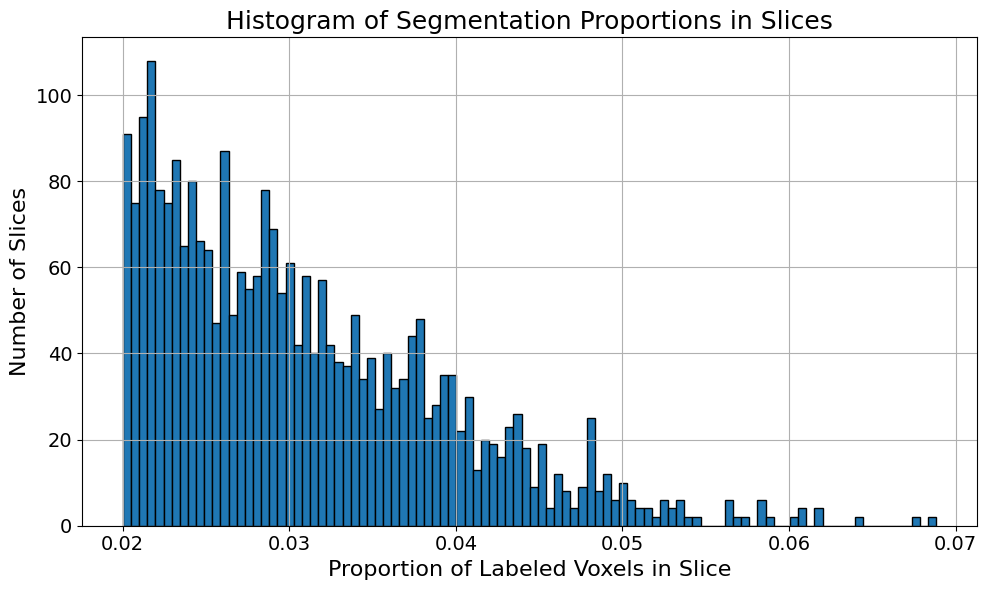

In [41]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

def plot_segmentation_histogram(slices_dir):
    # List all NIfTI files in the directory
    files = [f for f in os.listdir(slices_dir) if f.endswith('.nii.gz') or f.endswith('.nii')]
    files.sort()
    
    proportions = []

    for file_name in files:
        file_path = os.path.join(slices_dir, file_name)
        
        try:
            # Load the NIfTI file
            nii = nib.load(file_path)
            data = nii.get_fdata()
            
            # Ensure data is binary (0 or 1)
            data = np.where(data > 0, 1, 0)
            
            # Compute the proportion of labeled voxels in this chunk
            total_voxels = data.size
            labeled_voxels = np.count_nonzero(data)
            proportion = labeled_voxels / total_voxels
            proportions.append(proportion)
        except Exception as e:
            print(f"Error loading {file_path}. Error: {e}")
            continue

    # Plot histogram
    plt.figure(figsize=(10, 6))
    plt.hist(proportions, bins=100, edgecolor='black')
    plt.xlabel('Proportion of Labeled Voxels in Slice', fontsize=16)
    plt.ylabel('Number of Slices', fontsize=16)
    plt.title('Histogram of Segmentation Proportions in Slices', fontsize=18)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_segmentation_histogram(train_label_dir)

In [42]:
import os

# Define the folder path
folder_path = train_label_dir

print(folder_path)

# List all the .nii.gz files in the directory that start with 'mitochondria_' and end with '_0000.nii.gz'
nii_files = [f for f in os.listdir(folder_path) if f.startswith('mitochondria_') and f.endswith('_0000.nii.gz')]

# Loop through each .nii.gz file and rename
for nii_file in nii_files:
    # Construct the full path of the file
    full_path = os.path.join(folder_path, nii_file)
    
    # Remove the '_0000' from the file name and construct the new name
    new_file_name = nii_file.replace('_0000.nii.gz', '.nii.gz')
    new_full_path = os.path.join(folder_path, new_file_name)
    
    # Rename the file
    os.rename(full_path, new_full_path)

print("Renaming complete!")

/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw/Dataset3005_Mitochondria/labelsTr
Renaming complete!


In [43]:
print(train_image_dir)
print(train_label_dir)

/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw/Dataset3005_Mitochondria/imagesTr
/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw/Dataset3005_Mitochondria/labelsTr


In [44]:
train_files = os.listdir(train_image_dir)
label_files = os.listdir(train_label_dir)
print("train image files:",len(train_files))
print("train label files:",len(label_files))
print("Intersections:",len(set(train_files).intersection(set(label_files))))

train image files: 2666
train label files: 2666
Intersections: 0


In [45]:
#renaming to add the modality for SCGM there is only one modality 
#images should be added with 0000
#can be skipped if modality is already mentioned
#re-write for multiple modalities

def check_modality(filename):
    """
    check for the existence of modality
    return False if modality is not found else True
    """
    end = filename.find('.nii.gz')
    modality = filename[end-4:end]
    for mod in modality: 
        if not(ord(mod)>=48 and ord(mod)<=57): #if not in 0 to 9 digits
            return False
    return True

def rename_for_single_modality(directory):
    
    for file in os.listdir(directory):
        
        if check_modality(file)==False:
            new_name = file[:file.find('.nii.gz')]+"_0000.nii.gz"
            os.rename(os.path.join(directory,file),os.path.join(directory,new_name))
            print(f"Renamed to {new_name}")

rename_for_single_modality(train_image_dir)

In [46]:
task_folder_name

'/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw/Dataset3005_Mitochondria'

## Preprocessing

In [47]:
overwrite_json_file = True #make it True if you want to overwrite the dataset.json file in Dataset_folder
json_file_exist = False

if os.path.exists(os.path.join(task_folder_name,'dataset.json')):
    print('dataset.json already exist!')
    json_file_exist = True

if json_file_exist==False or overwrite_json_file:

    json_dict = OrderedDict()
    json_dict['name'] = dataset_name
    json_dict['description'] = "FIBSEM"
    json_dict['tensorImageSize'] = "3D"
    json_dict['reference'] = "N/A"
    json_dict['licence'] = "N/A"
    json_dict['release'] = "0.0"

    #you may mention more than one modality
    json_dict['channel_names'] = {
        "0": "SEM"
    }

    # set expected file ending
    json_dict["file_ending"] = ".nii.gz"

    #label names should be mentioned for all the labels in the dataset
    json_dict['labels'] = {
        "background": 0,
        "mitochondria": 1,
    }
    
    train_ids = os.listdir(train_label_dir)
    test_ids = os.listdir(test_dir)
    json_dict['numTraining'] = len(train_ids)
    json_dict['numTest'] = len(test_ids)
    
    with open(os.path.join(task_folder_name,"dataset.json"), 'w') as f:
        json.dump(json_dict, f, indent=4, sort_keys=True)

    if os.path.exists(os.path.join(task_folder_name,'dataset.json')):
        if json_file_exist==False:
            print('dataset.json created!')
        else: 
            print('dataset.json overwritten!')

dataset.json already exist!
dataset.json overwritten!


In [48]:
main_dir = '/home/home/Documents/'
main_dir = '/media/home/DATA10TB/MITOCHONDRIA/'

In [49]:
os.environ['nnUNet_raw_data_base'] = os.path.join(main_dir,'nnUNet_raw')
os.environ['nnUNet_preprocessed'] = os.path.join(main_dir,'nnUNet_preprocessed')
os.environ['RESULTS_FOLDER'] = os.path.join(main_dir,'nnUNet_results')

In [50]:
!nnUNetv2_plan_and_preprocess -d 3005 -c 3d_fullres --verify_dataset_integrity

Fingerprint extraction...
Dataset3005_Mitochondria
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Experiment planning...
Attempting to find 3d_lowres config. 
Current spacing: [1.03 1.03 1.03]. 
Current patch size: (256, 256, 32). 
Current median shape: [497.08737864 497.08737864  62.13592233]
Attempting to find 3d_lowres config. 
Current spacing: [1.0609 1.0609 1.0609]. 
Current patch size: (256, 256, 32). 
Current median shape: [482.60910548 482.60910548  60.32613818]
Attempting to find 3d_lowres config. 
Current spacing: [1.092727 1.092727 1.092727]. 
Current patch size: (256, 256, 32). 
Current median shape: [468.55252959 468.55252959  58.5690662 ]
Attempting to find 3d_lowres config. 
Current spacing: [1.12550881 1.12550881 1.12550881]. 
Current patch size: (256, 256, 32). 
Current median shape:

In [51]:
import json

# Assuming 'nnUNetPlans.json' is in the same directory as your script
file_name = os.path.join(os.environ['nnUNet_preprocessed'], dataset_name, 'nnUNetPlans.json')

# Load the JSON data from the file
with open(file_name, 'r') as file:
    data = json.load(file)

# Modify the 'patch_size' under 'configurations' -> '3d'
data['configurations']['3d_fullres']['patch_size'] = [352, 352, 128]
data['configurations']['3d_fullres']['batch_size'] = 2

# Save the modified data back to the file
with open(file_name, 'w') as file:
    json.dump(data, file, indent=4)

In [58]:
# === Install your volume-aware split and print a detailed summary (volumes + counts) ===
import os, json, shutil, time
from collections import Counter

# Reuse if already defined; otherwise default:
dataset_name = locals().get('dataset_name', 'Dataset3005_Mitochondria')

# Resolve raw & preprocessed roots (prefer the ones you used earlier)
RAW_BASE = os.environ.get('nnUNet_raw_data_base') or os.environ.get('nnUNet_raw', '/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw')
PP_ROOT  = os.environ.get('nnUNet_preprocessed', '/media/home/DATA10TB/MITOCHONDRIA/nnUNet_preprocessed')

raw_ds_dir = os.path.join(RAW_BASE, dataset_name)
pp_ds_dir  = os.path.join(PP_ROOT, dataset_name)

src_manual    = os.path.join(raw_ds_dir, 'splits_manual.json')
src_toplevel  = os.path.join(raw_ds_dir, 'splits_toplevel.json')  # optional, for echoing volume lists
dst_final     = os.path.join(pp_ds_dir,  'splits_final.json')
imagesTr_dir  = os.path.join(raw_ds_dir, 'imagesTr')

# --- 0) Load the manual split and basic validation ---
with open(src_manual, 'r') as f:
    splits = json.load(f)
assert isinstance(splits, list) and len(splits) == 5 and all('train' in s and 'val' in s for s in splits), \
    "splits_manual.json must be a list of 5 dicts with 'train' and 'val' keys."

# Gather case IDs present in imagesTr (nnU-Net uses the stem without _0000)
def to_case_id(fn):
    return fn.replace('.nii.gz','').replace('_0000','')

images_cases = {
    to_case_id(fn) for fn in os.listdir(imagesTr_dir) if fn.endswith('.nii.gz')
}

missing = {}
for i, s in enumerate(splits):
    miss_tr = sorted(set(s['train']) - images_cases)
    miss_va = sorted(set(s['val'])   - images_cases)
    if miss_tr or miss_va:
        missing[i] = {'train': miss_tr, 'val': miss_va}
if missing:
    raise ValueError(f"ERROR: Some split entries not found under imagesTr:\n{json.dumps(missing, indent=2)[:1000]}")

# --- 1) Install as the active split (backup any existing) ---
os.makedirs(pp_ds_dir, exist_ok=True)
if os.path.isfile(dst_final):
    backup = dst_final.replace('.json', f"_backup_{time.strftime('%Y%m%d_%H%M%S')}.json")
    shutil.copy2(dst_final, backup)
    print(f"[BACKUP] Existing split -> {backup}")

with open(dst_final, 'w') as f:
    json.dump(splits, f, indent=2)
print(f"[WRITE] Manual split installed -> {dst_final}\n")

# --- 2) Recreate the ‘Number of unique values (volumes)’ + per-volume counts ---
# Try to find your mapping file (you saved this earlier when chunking)
mapping_candidates = [
    'chunk_source_mapping_finetune.json',
    os.path.join(raw_ds_dir, 'chunk_source_mapping_finetune.json')
]
mapping_path = next((p for p in mapping_candidates if os.path.isfile(p)), None)

vol_counts = None
case_to_vol = {}
if mapping_path:
    with open(mapping_path, 'r') as f:
        mapping = json.load(f)   # keys: chunk filenames, values: volume name (e.g., VESSEL12_XX_combined.tif)
    # Per-volume counts (like your earlier print: counts of mapping entries, includes raw+label)
    vol_counts = Counter(mapping.values())
    uniq_vols = sorted(vol_counts.keys())
    print(f"Number of unique values (volumes): {len(uniq_vols)}\n")
    for vol in uniq_vols:
        print(f"{vol}: {vol_counts[vol]}")
    print()

    # Build a helper from case_id -> volume (use either the imag0e key or label key present in the mapping)
    def case_to_volume(k):
        # prefer image chunk name form
        cand_img = f"{k}_0000.nii.gz"
        cand_lab = f"{k}.nii.gz"
        if cand_img in mapping: return mapping[cand_img]
        if cand_lab in mapping: return mapping[cand_lab]
        return None
    # cache volumes per case to speed up
    for s in splits:
        for k in s['train'] + s['val']:
            if k not in case_to_vol:
                case_to_vol[k] = case_to_volume(k)

# --- 3) Echo each fold in the same style you printed earlier ---
def fold_volumes_from_toplevel(i):
    """If splits_toplevel.json exists, use it to echo volume lists exactly as created."""
    try:
        with open(src_toplevel, 'r') as f:
            tl = json.load(f)
        # tl[i] has: validation_volumes, training_volumes, total_*_keys
        return tl[i]['validation_volumes'], tl[i]['training_volumes']
    except Exception:
        return None, None

for i, s in enumerate(splits):
    fold_no = i + 1
    val_keys   = sorted(set(s['val']))
    train_keys = sorted(set(s['train']))

    val_vols, train_vols = fold_volumes_from_toplevel(i)
    # Fallback: infer volumes from mapping if toplevel absent
    if (not val_vols or not train_vols) and case_to_vol:
        val_vols   = sorted({case_to_vol[k] for k in val_keys   if case_to_vol.get(k)})
        train_vols = sorted({case_to_vol[k] for k in train_keys if case_to_vol.get(k)})
    # As a last resort, just show counts if we cannot resolve volumes
    if not val_vols:   val_vols   = []
    if not train_vols: train_vols = []

    print(f"Fold {fold_no}:")
    if val_vols:
        print(f"  Validation Volumes ({len(val_vols)}): {val_vols}")
    else:
        print(f"  Validation Volumes: (unavailable — no mapping/toplevel found)")
    print(f"  Total validation keys: {len(val_keys)}\n")

    if train_vols:
        print(f"  Training Volumes ({len(train_vols)}): {train_vols}")
    else:
        print(f"  Training Volumes: (unavailable — no mapping/toplevel found)")
    print(f"  Total training keys: {len(train_keys)}\n")

print("✓ Done. nnU-Net will now load this split file at training time.")
print("  (Reminder: your Fold 1–5 correspond to nnU-Net folds 0–4.)")

[BACKUP] Existing split -> /media/home/DATA10TB/MITOCHONDRIA/nnUNet_preprocessed/Dataset3005_Mitochondria/splits_final_backup_20250820_205703.json
[WRITE] Manual split installed -> /media/home/DATA10TB/MITOCHONDRIA/nnUNet_preprocessed/Dataset3005_Mitochondria/splits_final.json

Number of unique values (volumes): 20

VESSEL12_01_combined.tif: 18
VESSEL12_02_combined.tif: 206
VESSEL12_03_combined.tif: 220
VESSEL12_04_combined.tif: 44
VESSEL12_05_combined.tif: 162
VESSEL12_06_combined.tif: 118
VESSEL12_07_combined.tif: 112
VESSEL12_08_combined.tif: 182
VESSEL12_09_combined.tif: 280
VESSEL12_10_combined.tif: 60
VESSEL12_11_combined.tif: 92
VESSEL12_12_combined.tif: 124
VESSEL12_13_combined.tif: 56
VESSEL12_14_combined.tif: 94
VESSEL12_15_combined.tif: 138
VESSEL12_16_combined.tif: 68
VESSEL12_17_combined.tif: 128
VESSEL12_18_combined.tif: 114
VESSEL12_19_combined.tif: 114
VESSEL12_20_combined.tif: 104

Fold 1:
  Validation Volumes (4): ['VESSEL12_15_combined.tif', 'VESSEL12_12_combined.tif

In [59]:
import json
import os
import shutil
from datetime import datetime

# Define paths
dataset3005_name = 'Dataset3005_Mitochondria'
dataset4005_name = 'Dataset4005_Mitochondria'
preprocessed_dir = '/media/home/DATA10TB/MITOCHONDRIA/nnUNet_preprocessed'

# Paths to the plans files
dataset3005_plans_path = os.path.join(preprocessed_dir, dataset3005_name, 'nnUNetPlans.json')
dataset4005_plans_path = os.path.join(preprocessed_dir, dataset4005_name, 'nnUNetPlans.json')

# Create backup of original Dataset3005 plans
backup_path = dataset3005_plans_path.replace('.json', f'_backup_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json')
shutil.copy2(dataset3005_plans_path, backup_path)
print(f"Created backup: {backup_path}")

# Load both plans
with open(dataset3005_plans_path, 'r') as f:
    plans_3005 = json.load(f)
    
with open(dataset4005_plans_path, 'r') as f:
    plans_4005 = json.load(f)

# Copy the architecture from Dataset4005 to Dataset3005
# This ensures the network architecture matches exactly
plans_3005['configurations']['3d_fullres']['architecture'] = plans_4005['configurations']['3d_fullres']['architecture'].copy()

# Also ensure the patch size matches what you set for both
plans_3005['configurations']['3d_fullres']['patch_size'] = [352, 352, 128]
plans_3005['configurations']['3d_fullres']['batch_size'] = 2

# Print the changes for verification
print("\n=== Architecture Modification Summary ===")
print(f"Dataset3005 original n_stages: 7")
print(f"Dataset4005 (source) n_stages: {plans_4005['configurations']['3d_fullres']['architecture']['arch_kwargs']['n_stages']}")
print(f"Dataset3005 new n_stages: {plans_3005['configurations']['3d_fullres']['architecture']['arch_kwargs']['n_stages']}")

print(f"\nOriginal features_per_stage: (32, 64, 128, 256, 320, 320, 320)")
print(f"New features_per_stage: {plans_3005['configurations']['3d_fullres']['architecture']['arch_kwargs']['features_per_stage']}")

print(f"\nOriginal strides: ((1,1,1), (2,2,2), (2,2,2), (2,2,2), (2,2,1), (2,2,1), (2,2,1))")
print(f"New strides: {plans_3005['configurations']['3d_fullres']['architecture']['arch_kwargs']['strides']}")

# Save the modified plans
with open(dataset3005_plans_path, 'w') as f:
    json.dump(plans_3005, f, indent=4)
    
print(f"\n✓ Successfully modified {dataset3005_plans_path}")
print("✓ Architecture now matches Dataset4005")
print("\n⚠️  IMPORTANT: Do NOT re-run preprocessing after this modification!")
print("You can now proceed with finetuning using the pretrained weights.")

# Optional: Verify the key architecture parameters match
arch_3005 = plans_3005['configurations']['3d_fullres']['architecture']['arch_kwargs']
arch_4005 = plans_4005['configurations']['3d_fullres']['architecture']['arch_kwargs']

params_to_check = ['n_stages', 'features_per_stage', 'kernel_sizes', 'strides', 
                   'n_conv_per_stage', 'n_conv_per_stage_decoder']

print("\n=== Verification ===")
all_match = True
for param in params_to_check:
    if arch_3005[param] == arch_4005[param]:
        print(f"✓ {param}: MATCH")
    else:
        print(f"✗ {param}: MISMATCH")
        all_match = False
        
if all_match:
    print("\n✅ All architecture parameters match! Finetuning should work now.")
else:
    print("\n❌ Some parameters don't match. Please check the modifications.")

Created backup: /media/home/DATA10TB/MITOCHONDRIA/nnUNet_preprocessed/Dataset3005_Mitochondria/nnUNetPlans_backup_20250820_205712.json

=== Architecture Modification Summary ===
Dataset3005 original n_stages: 7
Dataset4005 (source) n_stages: 6
Dataset3005 new n_stages: 6

Original features_per_stage: (32, 64, 128, 256, 320, 320, 320)
New features_per_stage: [32, 64, 128, 256, 320, 320]

Original strides: ((1,1,1), (2,2,2), (2,2,2), (2,2,2), (2,2,1), (2,2,1), (2,2,1))
New strides: [[1, 1, 1], [2, 2, 2], [2, 2, 2], [2, 2, 2], [2, 2, 2], [2, 2, 1]]

✓ Successfully modified /media/home/DATA10TB/MITOCHONDRIA/nnUNet_preprocessed/Dataset3005_Mitochondria/nnUNetPlans.json
✓ Architecture now matches Dataset4005

⚠️  IMPORTANT: Do NOT re-run preprocessing after this modification!
You can now proceed with finetuning using the pretrained weights.

=== Verification ===
✓ n_stages: MATCH
✓ features_per_stage: MATCH
✓ kernel_sizes: MATCH
✓ strides: MATCH
✓ n_conv_per_stage: MATCH
✓ n_conv_per_stage_d

## Training nnU-Net

Generic Training Commands:

```nnUNetv2_train Dataset_NAME_OR_ID CONFIGURATION FOLD -tr TRAINER_CLASS_NAME (additional options)```

For 2D:  ```nnUNetv2_train DATASET_NAME_OR_ID 2d FOLD```

For 3D Full resolution: ```nnUNetv2_train DATASET_NAME_OR_ID 3d_fullres FOLD```

For Cascaded 3D:

First Run lowres: ```nnUNetv2_train DATASET_NAME_OR_ID 3d_lowres FOLD```

Then Run fullres: ```nnUNetv2_train DATASET_NAME_OR_ID 3d_cascade_fullres FOLD```

In [54]:
!nnUNetv2_train --help

usage: nnUNetv2_train [-h] [-tr TR] [-p P]
                      [-pretrained_weights PRETRAINED_WEIGHTS]
                      [-num_gpus NUM_GPUS] [--use_compressed] [--npz] [--c]
                      [--val] [--val_best] [--disable_checkpointing]
                      [-device DEVICE]
                      dataset_name_or_id configuration fold

positional arguments:
  dataset_name_or_id    Dataset name or ID to train with
  configuration         Configuration that should be trained
  fold                  Fold of the 5-fold cross-validation. Should be an int
                        between 0 and 4.

options:
  -h, --help            show this help message and exit
  -tr TR                [OPTIONAL] Use this flag to specify a custom trainer.
                        Default: nnUNetTrainer
  -p P                  [OPTIONAL] Use this flag to specify a custom plans
                        identifier. Default: nnUNetPlans
  -pretrained_weights PRETRAINED_WEIGHTS
                        [O

In [60]:
!nnUNetv2_train 3005 3d_fullres 0 -tr nnUNetTrainer_100epochs -pretrained_weights '/media/home/DATA10TB/MITOCHONDRIA/nnUNet_results/Dataset4005_Mitochondria/pretrained_weights/checkpoint_best.pth'

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

/home/home/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "
################### Loading pretrained weights from file  /media/home/DATA10TB/MITOCHONDRIA/nnUNet_results/Dataset4005_Mitochondria/pretrained_weights/checkpoint_best.pth ###################
Below is the list of overlapping blocks in pretrained model and nnUNet architecture:
encoder.stages.0.0.convs.0.conv.

In [ ]:
!nnUNetv2_train 3005 3d_fullres 1 -tr nnUNetTrainer_100epochs -pretrained_weights '/media/home/DATA10TB/MITOCHONDRIA/nnUNet_results/Dataset4005_Mitochondria/pretrained_weights/checkpoint_final.pth'

In [62]:
!nnUNetv2_train 3005 3d_fullres 2 -tr nnUNetTrainer_100epochs -pretrained_weights '/media/home/DATA10TB/MITOCHONDRIA/nnUNet_results/Dataset4005_Mitochondria/pretrained_weights/checkpoint_best.pth'

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

/home/home/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "
################### Loading pretrained weights from file  /media/home/DATA10TB/MITOCHONDRIA/nnUNet_results/Dataset4005_Mitochondria/pretrained_weights/checkpoint_best.pth ###################
Below is the list of overlapping blocks in pretrained model and nnUNet architecture:
encoder.stages.0.0.convs.0.conv.

In [ ]:
!nnUNetv2_train 3005 3d_fullres 3 -tr nnUNetTrainer_100epochs -pretrained_weights '/media/home/DATA10TB/MITOCHONDRIA/nnUNet_results/Dataset4005_Mitochondria/pretrained_weights/checkpoint_final.pth'

In [ ]:
!nnUNetv2_train 3005 3d_fullres 4 -tr nnUNetTrainer_100epochs -pretrained_weights '/media/home/DATA10TB/MITOCHONDRIA/nnUNet_results/Dataset4005_Mitochondria/pretrained_weights/checkpoint_final.pth'